# Lab 11 — Decision Tree (Solución)
Solución compacta: carga `iris`, entrena `DecisionTreeClassifier`, evalúa y dibuja matriz de confusión y árbol.

**Objetivo:** entender cómo entrenar y evaluar un árbol de decisión sobre el dataset `iris`.

**Pasos:**
- cargar datos
- separar en train/test
- entrenar `DecisionTreeClassifier`,
- evaluar con accuracy, reporte y matriz de confusión,
- visualizar el árbol para interpretación.

In [1]:
# Librerías necesarias para el flujo
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

seed = 42
np.random.seed(seed)

**Datos y modelo (explicación):**
- Usamos `iris` (3 clases).
- `train_test_split(..., stratify=y)` para mantener proporción de clases.
- `DecisionTreeClassifier(random_state=seed)` entrena un árbol por defecto; veremos la exactitud y el reporte de clasificación.

In [2]:
# Cargar y preparar datos
data = load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)

# Entrenar modelo
model = DecisionTreeClassifier(random_state=seed)
model.fit(X_train, y_train)

# Predicción y métricas
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.4f}')
print(classification_report(y_test, y_pred, target_names=data.target_names))

Test accuracy: 0.8947
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.80      0.92      0.86        13
   virginica       0.91      0.77      0.83        13

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.90      0.89      0.89        38



**Interpretación rápida:**
- `accuracy` muestra la proporción de predicciones correctas en el test.
- El `classification_report` aporta precision/recall/f1 por clase.
- La matriz de confusión muestra qué clases se confunden entre sí.

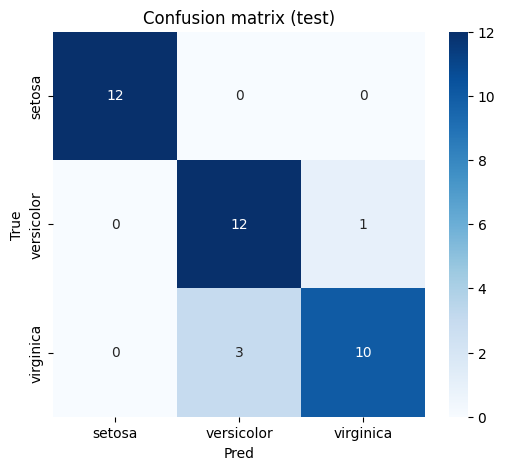

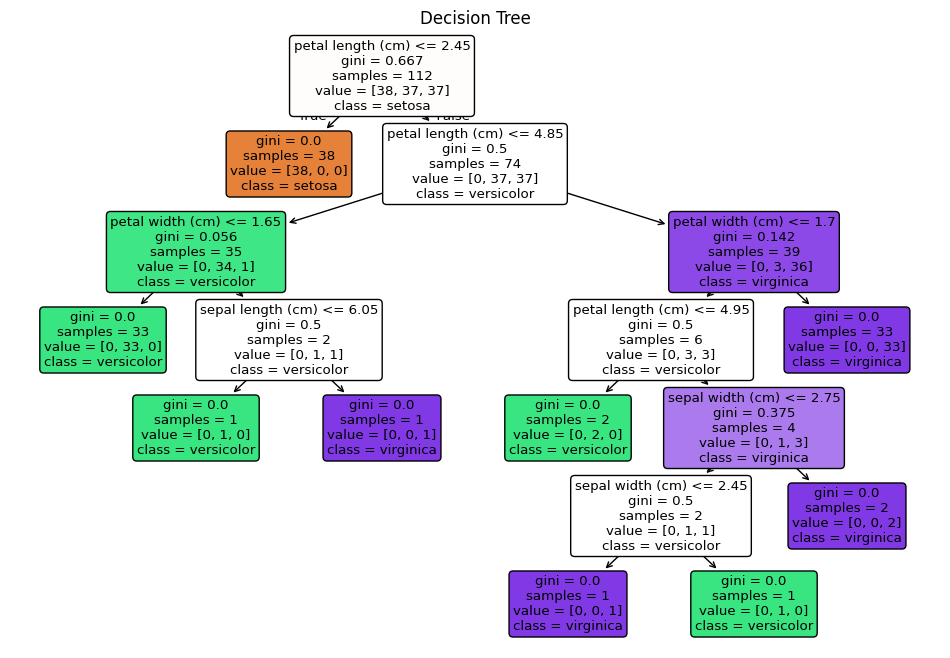

In [3]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Pred')
plt.ylabel('True')
plt.title('Confusion matrix (test)')
plt.show()

plt.figure(figsize=(12,8))
plot_tree(model, feature_names=data.feature_names, class_names=data.target_names, filled=True, rounded=True)
plt.title('Decision Tree')
plt.show()